# 03 — Data quality assessment

One section per quality dimension (Completeness, Consistency, Validity, Accuracy, Timeliness,
Uniqueness, Integrity, Representativeness), each finding reported as a NUMBER. **This notebook
only assesses — nothing here is fixed or cleaned.** Cleaning happens in `04_integrate.ipynb`,
after every finding below is written down. Summary table: `docs/QUALITY_FINDINGS.md`.

In [1]:
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

print("python", sys.version)
print("pandas", pd.__version__)

df_winter = pd.read_csv("../data/raw/311_2025-01_2025-02_downloaded_2026-07-12.csv", low_memory=False)
df_summer = pd.read_csv("../data/raw/311_2025-07_2025-08_downloaded_2026-07-12.csv", low_memory=False)
df = pd.concat([df_winter, df_summer], ignore_index=True)
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
df["closed_date"] = pd.to_datetime(df["closed_date"], errors="coerce")

wx = pd.read_csv("../data/raw/weather_centralpark_2025_downloaded_2026-07-12.csv")
wx["DATE"] = pd.to_datetime(wx["DATE"])

cat_map = pd.read_csv("../data/complaint_category_map.csv")

print("311 rows:", len(df))
print("weather rows:", len(wx))
print("mapping table rows:", len(cat_map))

python 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas 2.3.3


311 rows: 1223457
weather rows: 243
mapping table rows: 180


## 3.1 Completeness

**Decision:** report missing rates, don't invent values. Missing `closed_date` is legitimate for
cases that are still active (In Progress/Pending/Open/Assigned/Started) — but a case with
`status == "Closed"` and no `closed_date` is a genuine integrity anomaly, not an expected gap;
flagged here, not silently folded into "legitimate."

In [2]:
print("--- real NaNs, % per column (311, full data) ---")
print((df.isna().mean() * 100).round(2).sort_values(ascending=False))

print()
print("--- disguised missing values ---")
n_unspecified_borough = (df["borough"] == "Unspecified").sum()
print(f"borough == 'Unspecified': {n_unspecified_borough} ({n_unspecified_borough/len(df)*100:.2f}%)")

zip_str = df["incident_zip"].dropna().astype(int).astype(str).str.zfill(5)
n_zip_00000 = (zip_str == "00000").sum()
print(f"incident_zip == '00000': {n_zip_00000} ({n_zip_00000/len(df)*100:.3f}%)")

n_missing_closed = df["closed_date"].isna().sum()
missing_closed_status = df.loc[df["closed_date"].isna(), "status"].value_counts()
print(f"missing closed_date: {n_missing_closed} ({n_missing_closed/len(df)*100:.2f}%), by status:")
print(missing_closed_status)

n_still_active = missing_closed_status.drop("Closed", errors="ignore").sum()
n_closed_but_no_date = missing_closed_status.get("Closed", 0)
print(f"\n-> {n_still_active} ({n_still_active/n_missing_closed*100:.1f}%) are still-active cases "
      f"(In Progress/Pending/Open/Assigned/Started/Unspecified) -- legitimate, not a defect")
print(f"-> {n_closed_but_no_date} ({n_closed_but_no_date/n_missing_closed*100:.1f}%) have status == 'Closed' "
      f"but NO closed_date -- this is NOT legitimate, a genuine integrity anomaly, flagged (not fixed) here")

--- real NaNs, % per column (311, full data) ---


descriptor        2.60
closed_date       1.49
latitude          1.34
longitude         1.34
incident_zip      0.78
agency            0.00
unique_key        0.00
created_date      0.00
borough           0.00
complaint_type    0.00
agency_name       0.00
status            0.00
dtype: float64

--- disguised missing values ---
borough == 'Unspecified': 811 (0.07%)


incident_zip == '00000': 0 (0.000%)
missing closed_date: 18210 (1.49%), by status:
status
In Progress    13462
Closed          1883
Pending          957
Open             835
Assigned         646
Started          423
Unspecified        4
Name: count, dtype: int64

-> 16327 (89.7%) are still-active cases (In Progress/Pending/Open/Assigned/Started/Unspecified) -- legitimate, not a defect
-> 1883 (10.3%) have status == 'Closed' but NO closed_date -- this is NOT legitimate, a genuine integrity anomaly, flagged (not fixed) here


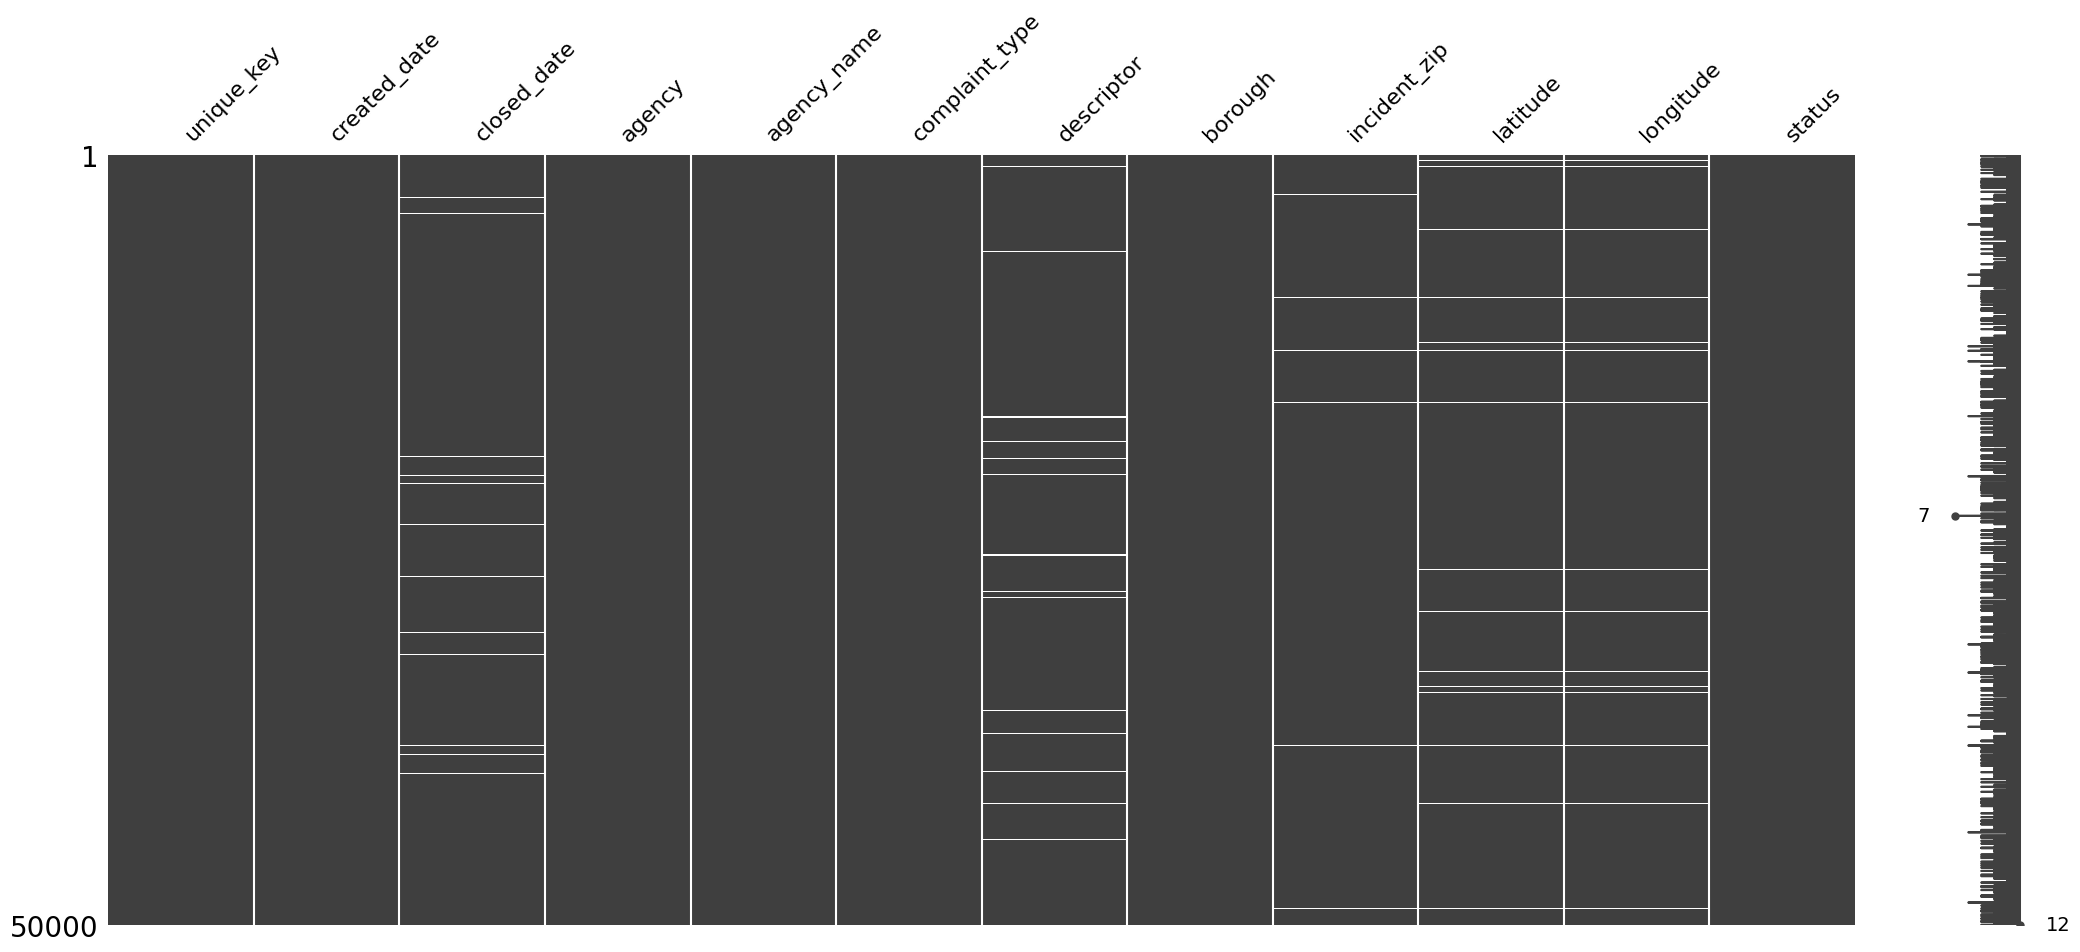

saved ../figures/fig_05_missingno_matrix.png (50k-row sample, for readability)


In [3]:
sample = df.sample(50_000, random_state=42)
fig = msno.matrix(sample).get_figure()
fig.savefig("../figures/fig_05_missingno_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved ../figures/fig_05_missingno_matrix.png (50k-row sample, for readability)")

In [4]:
full_calendar = pd.date_range(wx["DATE"].min(), wx["DATE"].max(), freq="D")
missing_wx_days = full_calendar.difference(wx["DATE"])
print(f"weather: {len(missing_wx_days)} missing calendar days out of {len(full_calendar)} expected")
print("weather missing values per column (%):")
print((wx.isna().mean() * 100).round(2))

weather: 0 missing calendar days out of 243 expected
weather missing values per column (%):
STATION    0.0
DATE       0.0
PRCP       0.0
SNOW       0.0
TMAX       0.0
TMIN       0.0
dtype: float64


## 3.2 Consistency

In [5]:
agency_map = df.groupby("agency")["agency_name"].nunique()
inconsistent_agencies = agency_map[agency_map > 1]
print(f"agency codes that map to more than one agency_name: {len(inconsistent_agencies)}")
print(inconsistent_agencies)

print()
print("--- borough value list (spelling variants?) ---")
print(df["borough"].value_counts(dropna=False))

agency codes that map to more than one agency_name: 0
Series([], Name: agency_name, dtype: int64)

--- borough value list (spelling variants?) ---
borough
BROOKLYN         350548
BRONX            298456
QUEENS           295369
MANHATTAN        233481
STATEN ISLAND     44792
Unspecified         811
Name: count, dtype: int64


In [6]:
n_whitespace = (df["complaint_type"] != df["complaint_type"].str.strip()).sum()
print(f"complaint_type values with leading/trailing whitespace: {n_whitespace}")

normalized = df["complaint_type"].str.strip().str.lower()
n_raw_types = df["complaint_type"].nunique()
n_normalized_types = normalized.nunique()
print(f"distinct complaint_type values: raw={n_raw_types}, after strip+lowercase={n_normalized_types}")
print(f"-> {n_raw_types - n_normalized_types} raw values are pure case/whitespace variants of another")

collapsed = pd.DataFrame({"raw": df["complaint_type"], "norm": normalized}).drop_duplicates()
dupe_groups = collapsed.groupby("norm")["raw"].apply(list)
dupe_groups = dupe_groups[dupe_groups.apply(len) > 1]
print(dupe_groups)

complaint_type values with leading/trailing whitespace: 0


distinct complaint_type values: raw=180, after strip+lowercase=178
-> 2 raw values are pure case/whitespace variants of another


norm
elevator    [Elevator, ELEVATOR]
plumbing    [PLUMBING, Plumbing]
Name: raw, dtype: object


## 3.3 Validity

In [7]:
zip_notna = df["incident_zip"].dropna().astype(int).astype(str).str.zfill(5)
zip_valid = zip_notna.str.match(r"^\d{5}$")
print(f"ZIP format ^\\d{{5}}$ pass rate: {zip_valid.mean()*100:.2f}% ({zip_valid.sum()}/{len(zip_notna)})")

NYC_LAT = (40.4, 41.0)
NYC_LON = (-74.3, -73.6)
coords = df[["latitude", "longitude"]].dropna()
in_box = coords["latitude"].between(*NYC_LAT) & coords["longitude"].between(*NYC_LON)
print(f"coordinates inside NYC bounding box: {in_box.mean()*100:.2f}% ({in_box.sum()}/{len(coords)})")
print(f"coordinates outside the box: {(~in_box).sum()}")

win1 = df["created_date"].between("2025-01-01", "2025-02-28 23:59:59")
win2 = df["created_date"].between("2025-07-01", "2025-08-31 23:59:59")
n_outside_window = (~(win1 | win2)).sum()
print(f"created_date rows outside the requested download windows: {n_outside_window}")

ZIP format ^\d{5}$ pass rate: 100.00% (1213975/1213975)
coordinates inside NYC bounding box: 100.00% (1207103/1207103)
coordinates outside the box: 0
created_date rows outside the requested download windows: 0


In [8]:
tmax_valid = wx["TMAX"].between(-30, 45)
tmin_valid = wx["TMIN"].between(-30, 45)
prcp_valid = wx["PRCP"] >= 0
snow_valid = wx["SNOW"] >= 0
print(f"TMAX within -30..45 C: {tmax_valid.mean()*100:.1f}% ({tmax_valid.sum()}/{len(wx)})")
print(f"TMIN within -30..45 C: {tmin_valid.mean()*100:.1f}% ({tmin_valid.sum()}/{len(wx)})")
print(f"PRCP >= 0: {prcp_valid.mean()*100:.1f}%")
print(f"SNOW >= 0: {snow_valid.mean()*100:.1f}%")

TMAX within -30..45 C: 100.0% (243/243)
TMIN within -30..45 C: 100.0% (243/243)
PRCP >= 0: 100.0%
SNOW >= 0: 100.0%


## 3.4 Accuracy

Hard to check without ground truth, especially for 311 (no independent record of what actually
happened at each address). For weather, spot-checked 2 extreme days in-window against independent
sources (National Weather Service NYC/OKX and search-aggregated news reporting):

| Date | Our value | External source | Agreement |
|---|---|---|---|
| 2025-01-22 (coldest TMIN in-window) | TMIN = −12.1 °C | NWS/press: 2025's lowest NYC temperature, 10 °F, occurred Jan 22 (10 °F = −12.2 °C) | within 0.1 °C |
| 2025-02-08 (biggest SNOW in-window) | SNOW = 76.0 mm | NWS event page "February 8–9, 2025 Snow, Sleet, and Ice Event" (weather.gov/okx/20250208_09): 3.1 in over Feb 8–9 (≈78.7 mm) | within ~3.5% (plausibly a day-boundary/measurement-window difference, since the official figure spans two days) |
| 2025-07-29 (hottest TMAX in-window) | TMAX = 36.1 °C | Press coverage confirms an active NYC heat wave around this date (second heat wave of summer 2025) | qualitative confirmation only — no exact published high found for this specific date |

**Decision:** treat the two close-agreement checks as good evidence the station data is accurate;
note the third as weaker (directionally consistent, not numerically verified) rather than
overstating confidence. 311 accuracy is disclosed as unverifiable at record level, not assessed
further — the daily-aggregation used later reduces the impact of any single mis-tagged report.

## 3.5 Timeliness

closed cases: 1205247 / 1223457 (98.5%)


count    1.205247e+06
mean     2.175575e+02
std      7.793686e+02
min     -1.752000e+03
25%      1.112500e+00
50%      8.393056e+00
75%      7.191819e+01
max      1.327256e+04
dtype: float64

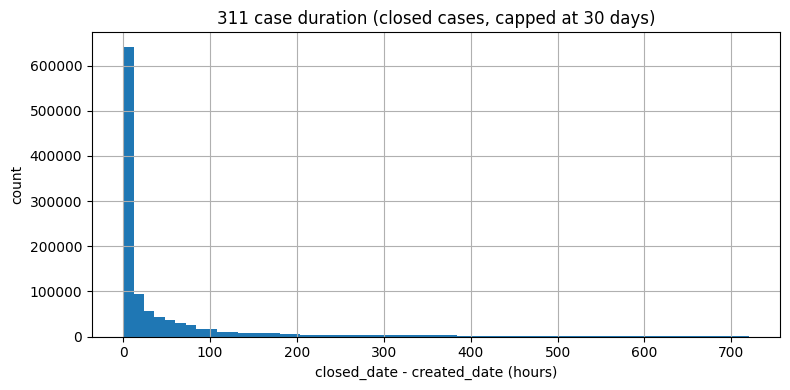


Download date for both sources: 2026-07-12 (data/DOWNLOAD_LOG.md).
NOAA daily-summaries values can be corrected retroactively after publication -- 'data as of 2026-07-12' applies to the weather file too.


In [9]:
duration = (df["closed_date"] - df["created_date"]).dt.total_seconds() / 3600  # hours
closed_mask = df["closed_date"].notna()
print(f"closed cases: {closed_mask.sum()} / {len(df)} ({closed_mask.mean()*100:.1f}%)")
print(duration[closed_mask].describe())

fig, ax = plt.subplots(figsize=(8, 4))
duration[closed_mask & (duration >= 0) & (duration < 24*30)].hist(bins=60, ax=ax)
ax.set_xlabel("closed_date - created_date (hours)")
ax.set_ylabel("count")
ax.set_title("311 case duration (closed cases, capped at 30 days)")
plt.tight_layout()
plt.savefig("../figures/fig_06_case_duration_hist.png", dpi=300)
plt.show()

print()
print("Download date for both sources: 2026-07-12 (data/DOWNLOAD_LOG.md).")
print("NOAA daily-summaries values can be corrected retroactively after publication -- 'data as of 2026-07-12' applies to the weather file too.")

## 3.6 Uniqueness

**Decision:** remove exact `unique_key` duplicates (there are none here, so nothing to drop);
keep semantic duplicates (same day+type+ZIP) deliberately — the unit of analysis is *reports*,
not *incidents*, and that choice is documented rather than silently baked in.

In [10]:
n_exact_dupes = df["unique_key"].duplicated().sum()
print(f"exact duplicate unique_key rows: {n_exact_dupes}")

df["_date"] = df["created_date"].dt.date
semantic_group_sizes = df.groupby(["_date", "complaint_type", "incident_zip"]).size()
semantic_dupe_groups = semantic_group_sizes[semantic_group_sizes > 1]
rows_in_semantic_dupes = semantic_dupe_groups.sum()
print(f"semantic-duplicate groups (same day+type+ZIP, size>1): {len(semantic_dupe_groups)}")
print(f"rows involved in those groups: {rows_in_semantic_dupes} ({rows_in_semantic_dupes/len(df)*100:.1f}% of all rows)")
print(f"largest such group: {semantic_dupe_groups.max()} reports")
df.drop(columns="_date", inplace=True)

exact duplicate unique_key rows: 0


semantic-duplicate groups (same day+type+ZIP, size>1): 183200
rows involved in those groups: 993543 (81.2% of all rows)
largest such group: 4989 reports


## 3.7 Integrity

In [11]:
n_negative_duration = (df["closed_date"] < df["created_date"]).sum()
print(f"rows with closed_date < created_date: {n_negative_duration} "
      f"({n_negative_duration/closed_mask.sum()*100:.3f}% of closed cases)")

merged = df[["complaint_type"]].merge(cat_map, left_on="complaint_type", right_on="raw_type", how="left")
n_unmapped = merged["category"].isna().sum()
print(f"complaint_type rows with no category mapping: {n_unmapped}")
print(f"distinct complaint_type values not covered by the mapping table: "
      f"{df.loc[~df['complaint_type'].isin(cat_map['raw_type']), 'complaint_type'].nunique()}")

rows with closed_date < created_date: 340 (0.028% of closed cases)


complaint_type rows with no category mapping: 0
distinct complaint_type values not covered by the mapping table: 0


## 3.8 Representativeness

Borough populations: 2020 US Census (via NYC Dept of City Planning / US Census Bureau QuickFacts;
see `docs/QUALITY_FINDINGS.md` for the citation links).

In [12]:
borough_pop_2020 = {
    "BROOKLYN": 2_736_074,
    "QUEENS": 2_405_464,
    "MANHATTAN": 1_694_251,
    "BRONX": 1_472_654,
    "STATEN ISLAND": 495_747,
}
complaints_per_borough = df[df["borough"].isin(borough_pop_2020)]["borough"].value_counts()

rep = pd.DataFrame({
    "complaints": complaints_per_borough,
    "population_2020": pd.Series(borough_pop_2020),
})
rep["complaints_per_1000_residents"] = (rep["complaints"] / rep["population_2020"] * 1000).round(1)
print(rep.sort_values("complaints_per_1000_residents", ascending=False))

print()
print("Weather: a single station (Central Park) stands in for the whole city -- coastal/outer-borough "
      "microclimates (e.g. Rockaways, Staten Island shoreline) can differ meaningfully, especially for "
      "precipitation and wind-driven events; this is a disclosed limitation, not something the data can fix.")

               complaints  population_2020  complaints_per_1000_residents
BRONX              298456          1472654                          202.7
MANHATTAN          233481          1694251                          137.8
BROOKLYN           350548          2736074                          128.1
QUEENS             295369          2405464                          122.8
STATEN ISLAND       44792           495747                           90.4

Weather: a single station (Central Park) stands in for the whole city -- coastal/outer-borough microclimates (e.g. Rockaways, Staten Island shoreline) can differ meaningfully, especially for precipitation and wind-driven events; this is a disclosed limitation, not something the data can fix.


## Next step

All findings above are transcribed into `docs/QUALITY_FINDINGS.md` as a *dimension | finding |
number | decision* summary table, alongside the `missingno` matrix and the `ydata-profiling`
report from Phase 2 as screenshots/links. No cleaning happens until `04_integrate.ipynb`.